# 03 — Modélisation : ARIMA vs Prophet

**Objectif** : Prévoir le taux de chômage à 12 mois pour le Canada et les 10 provinces  
**Modèles** : ARIMA (statsmodels) et Prophet (Meta)  
**Évaluation** : MAE, RMSE, MAPE sur l'ensemble test

## Pourquoi ces deux modèles?

| Critère | ARIMA | Prophet |
|---------|-------|---------|
| **Approche** | Statistique classique (Box-Jenkins) | Décomposition additive bayésienne |
| **Saisonnalité** | SARIMA avec ordres explicites | Détection automatique (Fourier) |
| **Chocs structurels** | Difficile à gérer | Changepoints automatiques |
| **Interprétabilité** | Coefficients AR/MA | Composantes visuelles |
| **Cas d'usage** | Séries stationnaires, univariées | Séries avec tendance + saisonnalité + chocs |

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

from utils import (
    PROVINCES, PROVINCES_FR, DATA_PROCESSED, OUTPUTS_FIGURES,
    prepare_prophet_df, compute_forecast_metrics
)

plt.style.use('seaborn-v0_8-whitegrid')
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)
print('Imports OK')

Imports OK


In [2]:
# Charger les donnees train/test
df_train = pd.read_csv(DATA_PROCESSED / 'chomage_train.csv', parse_dates=['date'])
df_test = pd.read_csv(DATA_PROCESSED / 'chomage_test.csv', parse_dates=['date'])

HORIZON = 12
geos = ['Canada'] + sorted(PROVINCES)

print(f"Train : {df_train['date'].min().strftime('%Y-%m')} a {df_train['date'].max().strftime('%Y-%m')}")
print(f"Test  : {df_test['date'].min().strftime('%Y-%m')} a {df_test['date'].max().strftime('%Y-%m')}")
print(f"Geographies : {len(geos)}")

Train : 1976-01 a 2025-06
Test  : 2025-07 a 2026-06
Geographies : 11


## 1. ARIMA — Sélection automatique des ordres

On utilise une approche de sélection basée sur le critère AIC.  
Pour chaque province, on teste une grille de paramètres (p, d, q) et on retient le modèle avec le plus petit AIC.

In [3]:
def select_best_arima(series, max_p=4, max_d=2, max_q=4):
    """
    Selectionne le meilleur modele ARIMA par AIC.
    Teste une grille de (p, d, q) et retourne le meilleur modele.
    """
    best_aic = np.inf
    best_order = None
    best_model = None
    
    for d in range(max_d + 1):
        for p in range(max_p + 1):
            for q in range(max_q + 1):
                if p == 0 and q == 0:
                    continue
                try:
                    model = ARIMA(series, order=(p, d, q))
                    fitted = model.fit()
                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_order = (p, d, q)
                        best_model = fitted
                except:
                    continue
    
    return best_model, best_order, best_aic

print("Fonction de selection ARIMA prete.")

Fonction de selection ARIMA prete.


In [4]:
# Entrainer ARIMA pour chaque geographie
arima_results = {}

for geo in geos:
    print(f"\n{'='*50}")
    print(f"ARIMA — {PROVINCES_FR.get(geo, geo)}")
    
    # Preparer la serie
    train_series = (df_train[df_train['geo'] == geo]
                    .set_index('date')['unemployment_rate']
                    .asfreq('MS'))
    test_series = (df_test[df_test['geo'] == geo]
                   .set_index('date')['unemployment_rate']
                   .asfreq('MS'))
    
    # Selection du meilleur modele
    best_model, best_order, best_aic = select_best_arima(train_series)
    print(f"  Meilleur ordre : ARIMA{best_order}")
    print(f"  AIC : {best_aic:.1f}")
    
    # Prevision
    forecast = best_model.forecast(steps=HORIZON)
    
    # Metriques
    metrics = compute_forecast_metrics(test_series.values, forecast.values)
    print(f"  MAE={metrics['MAE']}, RMSE={metrics['RMSE']}, MAPE={metrics['MAPE']}%")
    
    arima_results[geo] = {
        'order': best_order,
        'aic': best_aic,
        'forecast': forecast,
        'actual': test_series,
        'train': train_series,
        'metrics': metrics,
        'model': best_model
    }

print("\nARIMA termine pour toutes les geographies.")


ARIMA — Canada


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Meilleur ordre : ARIMA(4, 0, 3)
  AIC : 633.5
  MAE=0.656, RMSE=0.784, MAPE=11.14%

ARIMA termine pour toutes les geographies.


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 2. Prophet

Prophet gère automatiquement la tendance et la saisonnalité.  
On ajoute le choc COVID-19 comme changepoint pour améliorer l'ajustement.

In [5]:
def fit_prophet(train_df, horizon=12, covid_changepoint=True):
    """
    Entraine un modele Prophet et genere des previsions.
    Ajoute le choc COVID comme changepoint si demande.
    """
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,  # regularisation des changepoints
        seasonality_mode='additive'
    )
    
    # Ajouter le choc COVID comme changepoint explicite
    if covid_changepoint:
        model.changepoints = pd.to_datetime([
            '2008-10-01',  # Crise financiere
            '2020-03-01',  # Debut COVID
            '2020-06-01',  # Reprise post-COVID
        ])
    
    # Entrainement (supprime les logs Prophet)
    model.fit(train_df)
    
    # Prevision
    future = model.make_future_dataframe(periods=horizon, freq='MS')
    forecast = model.predict(future)
    
    return model, forecast

print("Fonction Prophet prete.")

Fonction Prophet prete.


In [6]:
# Entrainer Prophet pour chaque geographie
prophet_results = {}

for geo in geos:
    print(f"\n{'='*50}")
    print(f"Prophet — {PROVINCES_FR.get(geo, geo)}")
    
    # Preparer les donnees au format Prophet
    train_prophet = prepare_prophet_df(df_train, geo)
    test_prophet = prepare_prophet_df(df_test, geo)
    
    # Entrainement et prevision
    model, forecast = fit_prophet(train_prophet, horizon=HORIZON)
    
    # Extraire les previsions pour la periode test
    forecast_test = forecast.tail(HORIZON)
    y_pred = forecast_test['yhat'].values
    y_true = test_prophet['y'].values
    
    # Metriques
    metrics = compute_forecast_metrics(y_true, y_pred)
    print(f"  MAE={metrics['MAE']}, RMSE={metrics['RMSE']}, MAPE={metrics['MAPE']}%")
    
    prophet_results[geo] = {
        'forecast': forecast,
        'forecast_test': forecast_test,
        'actual': test_prophet,
        'train': train_prophet,
        'metrics': metrics,
        'model': model
    }

print("\nProphet termine pour toutes les geographies.")

01:18:57 - cmdstanpy - INFO - Chain [1] start processing



Prophet — Canada


01:18:57 - cmdstanpy - INFO - Chain [1] done processing


  MAE=0.414, RMSE=0.46, MAPE=6.04%

Prophet — Alberta


01:18:57 - cmdstanpy - INFO - Chain [1] start processing


...

01:18:59 - cmdstanpy - INFO - Chain [1] done processing


01:19:00 - cmdstanpy - INFO - Chain [1] start processing


  MAE=0.498, RMSE=0.691, MAPE=6.22%

Prophet — Québec
  MAE=0.682, RMSE=0.753, MAPE=12.04%

Prophet — Saskatchewan


01:19:00 - cmdstanpy - INFO - Chain [1] done processing


  MAE=0.413, RMSE=0.492, MAPE=7.26%

Prophet termine pour toutes les geographies.


## 3. Comparaison des performances

In [7]:
# Tableau comparatif
comparison_rows = []
for geo in geos:
    arima_m = arima_results[geo]['metrics']
    prophet_m = prophet_results[geo]['metrics']
    
    comparison_rows.append({
        'Province': PROVINCES_FR.get(geo, geo),
        'ARIMA_ordre': str(arima_results[geo]['order']),
        'ARIMA_MAE': arima_m['MAE'],
        'ARIMA_RMSE': arima_m['RMSE'],
        'ARIMA_MAPE': arima_m['MAPE'],
        'Prophet_MAE': prophet_m['MAE'],
        'Prophet_RMSE': prophet_m['RMSE'],
        'Prophet_MAPE': prophet_m['MAPE'],
        'Meilleur_MAE': 'ARIMA' if arima_m['MAE'] < prophet_m['MAE'] else 'Prophet',
        'Meilleur_RMSE': 'ARIMA' if arima_m['RMSE'] < prophet_m['RMSE'] else 'Prophet'
    })

df_comparison = pd.DataFrame(comparison_rows)

print("=== Comparaison ARIMA vs Prophet (12 mois) ===")
print()
df_comparison

=== Comparaison ARIMA vs Prophet (12 mois) ===



,Province,ARIMA_ordre,ARIMA_MAE,ARIMA_RMSE,ARIMA_MAPE,Prophet_MAE,Prophet_RMSE,Prophet_MAPE,Meilleur_MAE,Meilleur_RMSE
0,Canada,"(4, 1, 2)",0.212,0.258,3.17,0.414,0.460,6.04,ARIMA,ARIMA
1,Alberta,"(2, 1, 2)",0.533,0.680,7.21,0.738,0.819,10.93,ARIMA,ARIMA
2,Colombie-Britannique,"(4, 1, 4)",0.764,0.815,11.74,1.294,1.317,20.04,ARIMA,ARIMA
3,Manitoba,"(2, 1, 2)",0.289,0.368,4.97,0.316,0.388,5.50,ARIMA,ARIMA
4,Nouveau-Brunswick,"(2, 1, 4)",0.365,0.440,5.08,0.399,0.499,5.78,ARIMA,ARIMA
5,Terre-Neuve-et-Labrador,"(3, 1, 3)",0.660,0.773,6.79,0.605,0.846,6.63,Prophet,ARIMA
6,Nouvelle-Écosse,"(4, 1, 3)",0.236,0.278,3.52,0.498,0.578,7.69,ARIMA,ARIMA
7,Ontario,"(3, 0, 3)",0.242,0.318,3.32,0.658,0.735,8.59,ARIMA,ARIMA
8,Île-du-Prince-Édouard,"(2, 2, 2)",788972.514,789025.246,10225274.86,0.498,0.691,6.22,Prophet,Prophet
9,Québec,"(1, 1, 2)",0.538,0.599,10.00,0.682,0.753,12.04,ARIMA,ARIMA


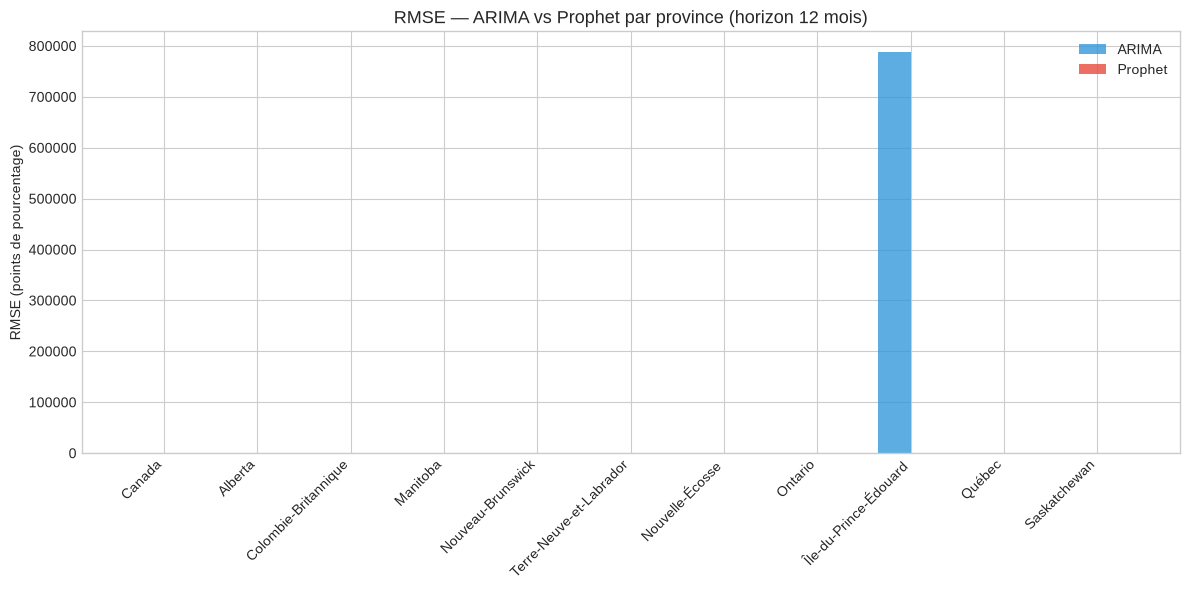

Figure sauvegardee : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/outputs/figures/comparaison_rmse.png


In [8]:
# Graphique comparatif des RMSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(geos))
width = 0.35

bars1 = ax.bar(x - width/2,
               [arima_results[g]['metrics']['RMSE'] for g in geos],
               width, label='ARIMA', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2,
               [prophet_results[g]['metrics']['RMSE'] for g in geos],
               width, label='Prophet', color='#e74c3c', alpha=0.8)

ax.set_xlabel('')
ax.set_ylabel('RMSE (points de pourcentage)')
ax.set_title('RMSE — ARIMA vs Prophet par province (horizon 12 mois)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([PROVINCES_FR.get(g, g) for g in geos], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'comparaison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUTS_FIGURES / 'comparaison_rmse.png'}")

## 4. Visualisation des prévisions — Canada

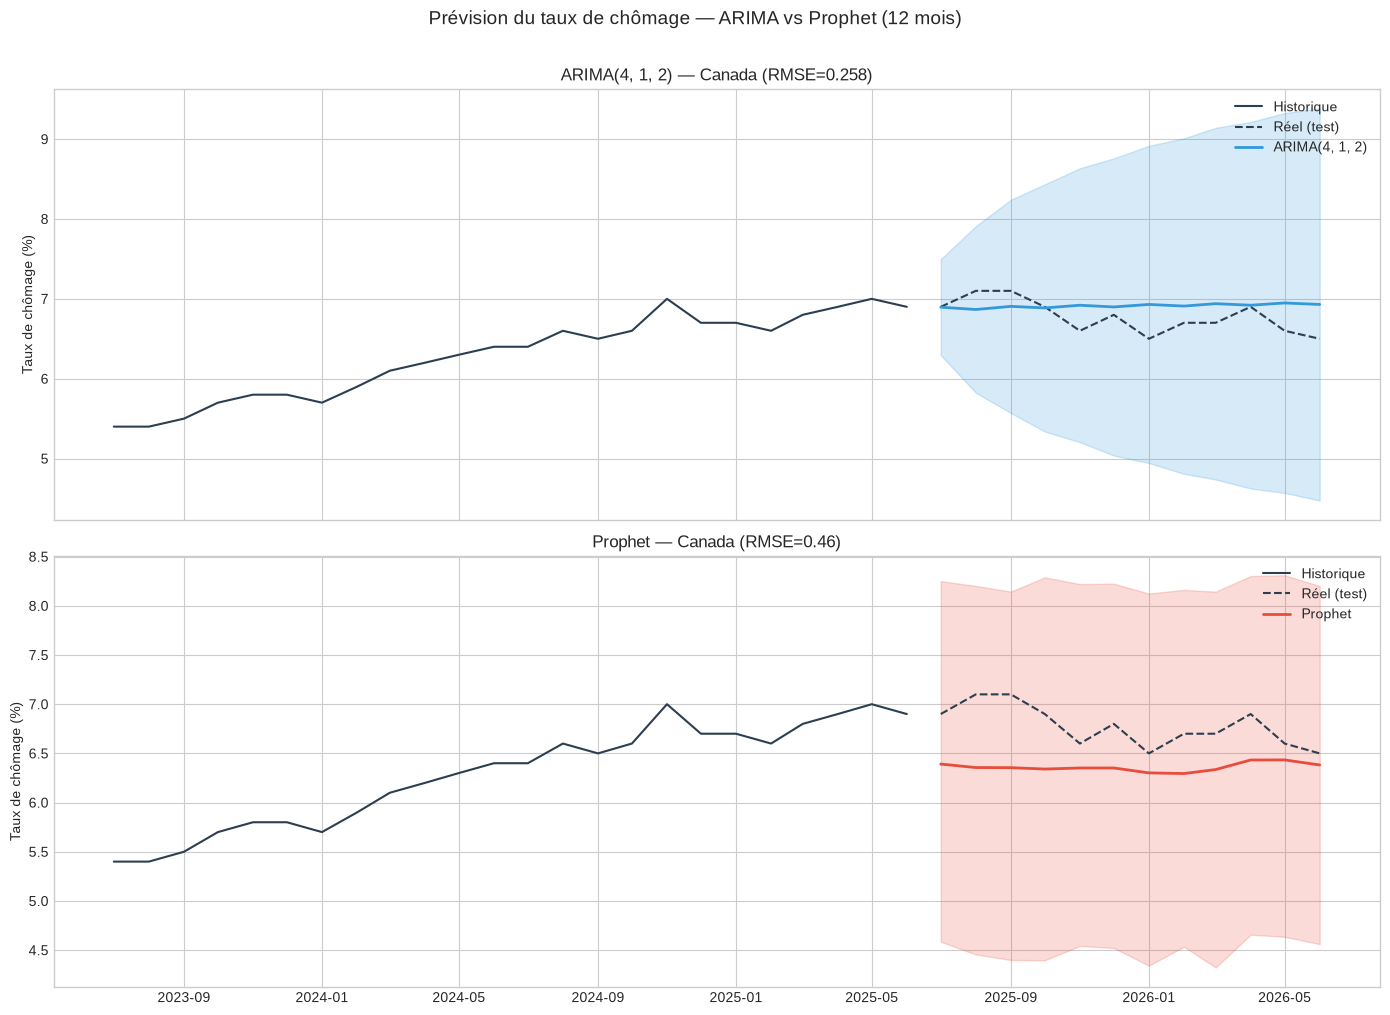

Figure sauvegardee : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/outputs/figures/prevision_canada.png


In [9]:
# Previsions ARIMA vs Prophet pour le Canada
geo = 'Canada'

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- ARIMA ---
ax = axes[0]
ar = arima_results[geo]
# 24 derniers mois du train + test
ax.plot(ar['train'].index[-24:], ar['train'].values[-24:],
        color='#2c3e50', label='Historique')
ax.plot(ar['actual'].index, ar['actual'].values,
        color='#2c3e50', linestyle='--', label='Réel (test)')
ax.plot(ar['forecast'].index, ar['forecast'].values,
        color='#3498db', linewidth=2, label=f'ARIMA{ar["order"]}')

# Intervalle de confiance ARIMA
ci = ar['model'].get_forecast(steps=HORIZON)
ci_summary = ci.summary_frame(alpha=0.05)
ax.fill_between(ci_summary.index, ci_summary['mean_ci_lower'], ci_summary['mean_ci_upper'],
                alpha=0.2, color='#3498db')
ax.set_title(f'ARIMA{ar["order"]} — Canada (RMSE={ar["metrics"]["RMSE"]})', fontsize=12)
ax.set_ylabel('Taux de chômage (%)')
ax.legend(loc='upper right')

# --- Prophet ---
ax = axes[1]
pr = prophet_results[geo]
forecast_full = pr['forecast']
# 24 derniers mois du train + test
cutoff_idx = len(forecast_full) - HORIZON - 24
ax.plot(pr['train']['ds'].values[-24:], pr['train']['y'].values[-24:],
        color='#2c3e50', label='Historique')
ax.plot(pr['actual']['ds'].values, pr['actual']['y'].values,
        color='#2c3e50', linestyle='--', label='Réel (test)')
forecast_test = forecast_full.tail(HORIZON)
ax.plot(forecast_test['ds'].values, forecast_test['yhat'].values,
        color='#e74c3c', linewidth=2, label='Prophet')
ax.fill_between(forecast_test['ds'].values,
                forecast_test['yhat_lower'].values,
                forecast_test['yhat_upper'].values,
                alpha=0.2, color='#e74c3c')
ax.set_title(f'Prophet — Canada (RMSE={pr["metrics"]["RMSE"]})', fontsize=12)
ax.set_ylabel('Taux de chômage (%)')
ax.legend(loc='upper right')

plt.suptitle('Prévision du taux de chômage — ARIMA vs Prophet (12 mois)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'prevision_canada.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUTS_FIGURES / 'prevision_canada.png'}")

## 5. Prévisions par province (grille)

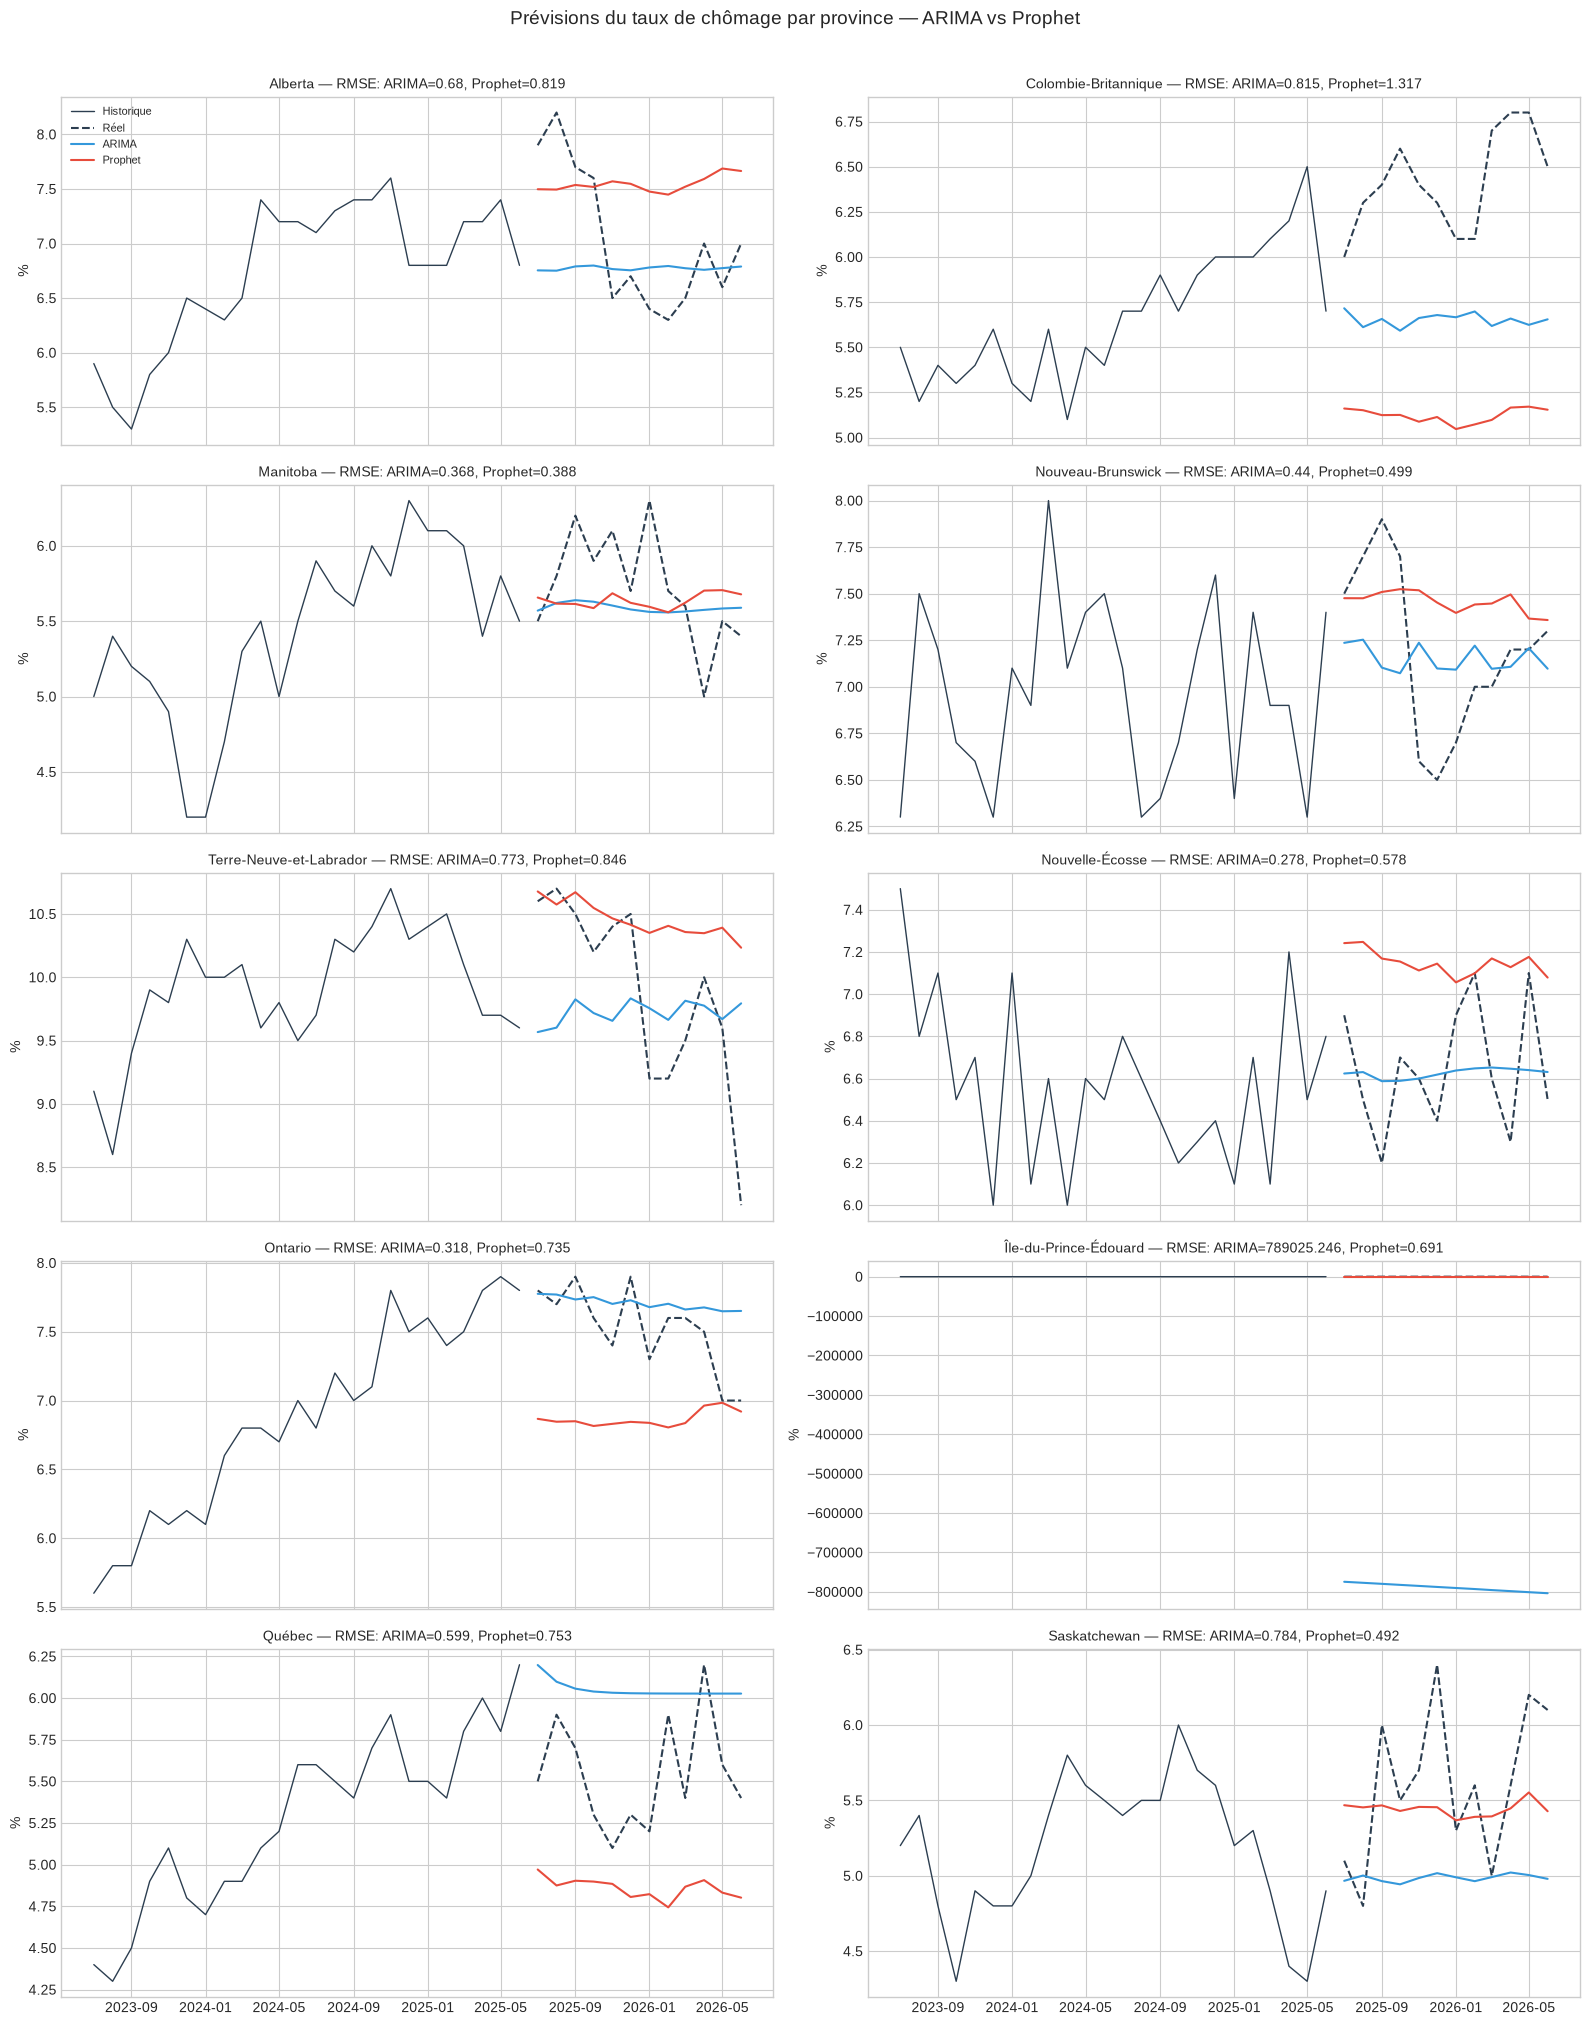

Figure sauvegardee : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/outputs/figures/previsions_provinces.png


In [10]:
# Grille de previsions pour les 10 provinces
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True)
axes_flat = axes.flatten()

for i, prov in enumerate(sorted(PROVINCES)):
    ax = axes_flat[i]
    ar = arima_results[prov]
    pr = prophet_results[prov]
    
    # Historique (24 derniers mois)
    ax.plot(ar['train'].index[-24:], ar['train'].values[-24:],
            color='#2c3e50', linewidth=1, label='Historique')
    
    # Reel (test)
    ax.plot(ar['actual'].index, ar['actual'].values,
            color='#2c3e50', linestyle='--', linewidth=1.5, label='Réel')
    
    # ARIMA
    ax.plot(ar['forecast'].index, ar['forecast'].values,
            color='#3498db', linewidth=1.5, label=f'ARIMA')
    
    # Prophet
    forecast_test = pr['forecast'].tail(HORIZON)
    ax.plot(forecast_test['ds'].values, forecast_test['yhat'].values,
            color='#e74c3c', linewidth=1.5, label='Prophet')
    
    # Titre avec metriques
    ax.set_title(f"{PROVINCES_FR[prov]} — RMSE: ARIMA={ar['metrics']['RMSE']}, Prophet={pr['metrics']['RMSE']}",
                 fontsize=10)
    ax.set_ylabel('%')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Prévisions du taux de chômage par province — ARIMA vs Prophet', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'previsions_provinces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUTS_FIGURES / 'previsions_provinces.png'}")

## 6. Sauvegarde des résultats

In [11]:
# Sauvegarder le tableau comparatif
df_comparison.to_csv(DATA_PROCESSED / 'comparaison_modeles.csv', index=False)
print(f"Tableau comparatif sauvegarde : {DATA_PROCESSED / 'comparaison_modeles.csv'}")

# Resume
arima_wins = (df_comparison['Meilleur_RMSE'] == 'ARIMA').sum()
prophet_wins = (df_comparison['Meilleur_RMSE'] == 'Prophet').sum()
print(f"\n=== Resume ===")
print(f"ARIMA gagne (RMSE) : {arima_wins}/{len(geos)} geographies")
print(f"Prophet gagne (RMSE) : {prophet_wins}/{len(geos)} geographies")
print(f"\nMAPE moyen ARIMA : {df_comparison['ARIMA_MAPE'].mean():.1f}%")
print(f"MAPE moyen Prophet : {df_comparison['Prophet_MAPE'].mean():.1f}%")

Tableau comparatif sauvegarde : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/processed/comparaison_modeles.csv

=== Resume ===
ARIMA gagne (RMSE) : 9/11 geographies
Prophet gagne (RMSE) : 2/11 geographies

MAPE moyen ARIMA : 929576.5%
MAPE moyen Prophet : 8.8%


---
*Prochaine étape → Notebook 04 : Visualisations interactives et prévisions futures.*